In [1]:
import BiSSGL as BiSSGL
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
import inspect

In [ ]:
# This is new simulation setting for the feature selection:
I = 80
J = 160
d = d1 = d2 = 10
K = K1 = K2 = 3

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

In [2]:
# This is new simulation setting for the feature selection:
I = 80
J = 160
d = d1 = d2 = 10
K = K1 = K2 = 3

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.ones((K, K))
B_true = np.ones((K, K))

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

In [3]:
# U.shape, V.shape, A_true.shape
A = np.zeros((d1, K))
A[range(K), range(K)] = 1

B = np.zeros((d2, K))
B[range(K), range(K)] = 1

In [4]:
print(A_true)

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


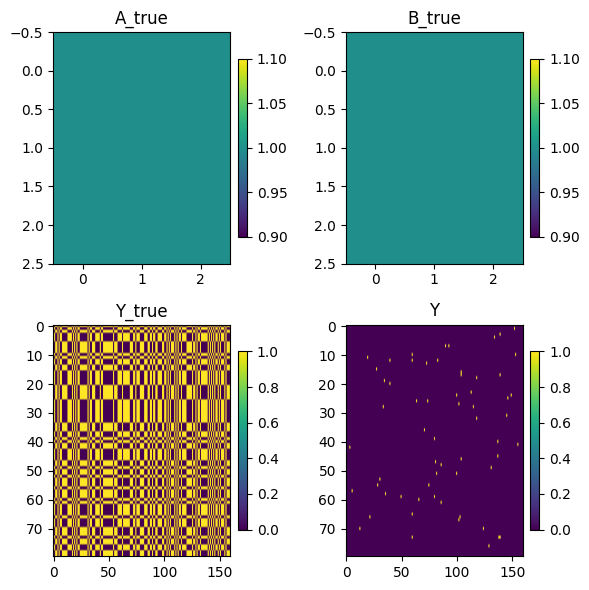

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes[0, 0].imshow(A_true, aspect="auto", cmap="viridis")
axes[0, 0].set_title("A_true")
plt.colorbar(axes[0, 0].images[0], ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].imshow(B_true, aspect="auto", cmap="viridis")
axes[0, 1].set_title("B_true")
plt.colorbar(axes[0, 1].images[0], ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].imshow(Y_true, aspect="auto", cmap="viridis")
axes[1, 0].set_title("Y_true")
plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(Y, aspect="auto", cmap="viridis")
axes[1, 1].set_title("Y")
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [5]:
est_mu, est_A, est_B = BiSSGL.optimization(
    Y_true,
    U=U,
    V=V,
    xi=1,
    eta=1e-5,
    tilde_lambda0=1,
    tilde_lambda1=1,
    tilde_alpha=1,
    tilde_beta=1,
    lambda0=1,
    lambda1=1,
    alpha=1,
    beta=1,
    K=3,
    max_iter=5000,
    tol=1e-12,
    # A = A,
    # B = B
)

Finished with iterations of 4999


In [6]:
print(est_mu)

[ 0.  0. -0.  0.  0.  0.  0.  0.  0. -0.  0.  0. -0. -0.  0. -0.  0.  0.
 -0.  0. -0. -0. -0. -0. -0. -0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0.
 -0.  0.  0.  0. -0. -0.  0. -0. -0. -0.  0.  0.  0.  0.  0.  0.  0.  0.
 -0. -0. -0.  0.  0.  0. -0. -0.  0. -0.  0.  0. -0.  0.  0. -0. -0. -0.
 -0. -0.  0.  0.  0.  0. -0.  0.]


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns  # optional, for nicer heatmaps


def plot_matrices(U, V):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.heatmap(U, ax=axes[0], cmap="viridis", cbar=True)
    axes[0].set_title("Latent Matrix U")

    sns.heatmap(V, ax=axes[1], cmap="viridis", cbar=True)
    axes[1].set_title("Latent Matrix V")

    plt.tight_layout()
    plt.show()

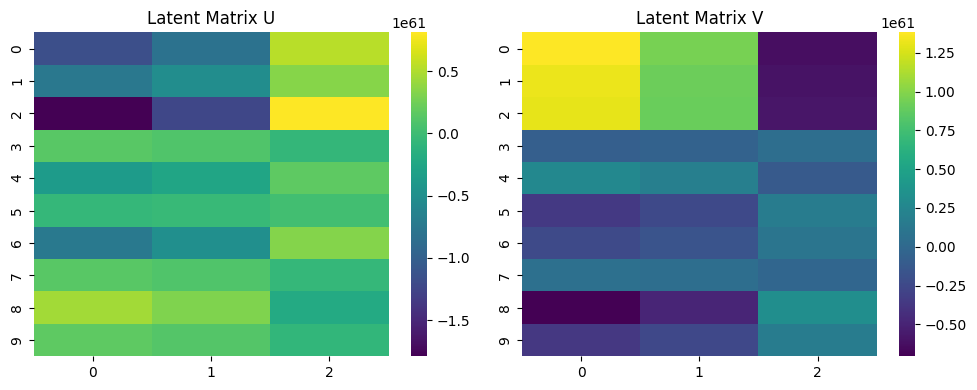

In [8]:
plot_matrices(est_A, est_B)

In [22]:
np.abs(est_A)

array([[9.98985623e+66, 2.79699071e+67, 2.37893056e+67],
       [5.35441088e+66, 1.49914444e+67, 1.27507057e+67],
       [6.11863837e+66, 1.71311521e+67, 1.45705959e+67],
       [1.21996407e+66, 3.41569297e+66, 2.90515673e+66],
       [1.20155567e+66, 3.36415256e+66, 2.86131996e+66],
       [1.56346995e+65, 4.37745132e+65, 3.72316315e+65],
       [3.56762984e+66, 9.98875988e+66, 8.49576157e+66],
       [1.13931917e+66, 3.18990090e+66, 2.71311332e+66],
       [1.38443529e+65, 3.87618454e+65, 3.29681963e+65],
       [1.79013878e+66, 5.01208568e+66, 4.26294009e+66]])

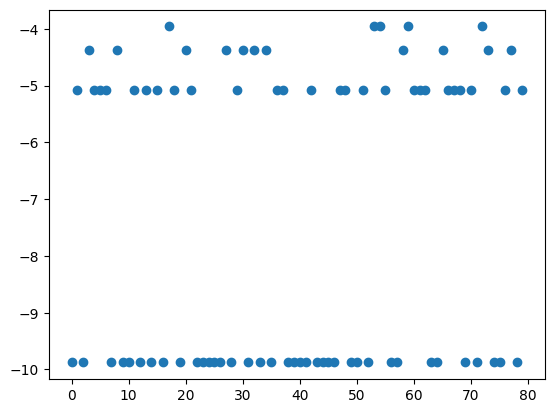

In [31]:
plt.scatter(range(len(est_mu)), est_mu)

In [38]:
print(inspect.getsource(BiSSGL.optimization))

def optimization(
    Y,
    U,
    V,
    xi,
    eta,
    tilde_lambda0,
    tilde_lambda1,
    tilde_alpha,
    tilde_beta,
    lambda0,
    lambda1,
    alpha,
    beta,
    K=None,
    mu=None,
    A=None,
    B=None,
    seed=None,
    max_iter=100,
    tol=1e-3,
):

    d1 = U.shape[1]
    d2 = V.shape[1]

    # Initialize K
    if K is None:
        if A is None and B is None:
            K = len(np.linalg.svd(Y).S)
        else:
            ncol_a = A.shape[1] if A is not None else 0
            ncol_b = B.shape[1] if B is not None else 0
        K = max(ncol_a, ncol_b)

    # Initialize A and B
    if A is None:
        if seed is not None:
            np.random.seed(seed)
            A = np.sqrt(1 / K) * np.random.normal(size=(d1, K))
        else:
            A = np.sqrt(1 / K) * np.random.normal(size=(d1, K))
    if B is None:
        if seed is not None:
            np.random.seed(seed)
            B = np.sqrt(1 / K) * np.random.normal(size=(d2, K))
        else:
        

In [ ]:
data = np.genfromtxt(
    "/Users/sijianfan/Documents/projects/SSLMC/codes/DRIMC/c_admat_dgc.txt",
    delimiter="\t",
    skip_header=1,
)[:, 1:]
print(data.shape)
print(data)

(409, 658)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


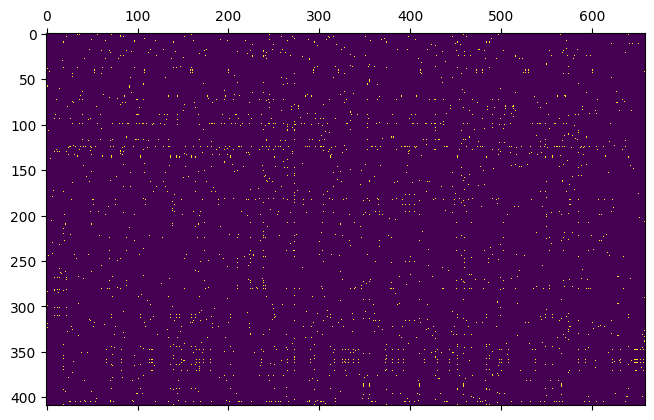

In [45]:
plt.matshow(data)

In [54]:
I = data.shape[0]
J = data.shape[1]

U = np.diag(np.ones(I))
V = np.diag(np.ones(J))

In [55]:
est_mu, est_A, est_B = BiSSGL.optimization(
    data,
    U=U,
    V=V,
    xi=1,
    eta=1e-5,
    tilde_lambda0=1,
    tilde_lambda1=1,
    tilde_alpha=1,
    tilde_beta=1,
    lambda0=1,
    lambda1=1,
    alpha=1,
    beta=1,
    K=20,
    max_iter=5000,
    tol=1e-12,
    # A = A,
    # B = B
)

Finished with iterations of 4999


In [56]:
est_mu

array([-7853.89701359, -9060.07648378, -7874.39805441, -7623.47249528,
       -9312.89223626, -9298.42110359, -9263.8123575 , -9172.64852252,
       -9102.40117661, -9170.28981744, -9181.97693972, -7803.03307895,
       -9211.99091486, -7880.47510122, -9312.29529532, -7912.24170017,
       -7754.96732173, -7888.93936211, -7573.97665563, -7673.89936897,
       -7789.55203165, -7780.96884824, -9299.04342337, -9303.54167786,
       -7357.33131122, -9241.76682382, -7907.99059259, -9211.71742504,
       -7643.92383592, -7921.6249449 , -7869.17483426, -9313.24744367,
       -7895.29715229, -9294.31651344, -7881.0308497 , -9299.82521329,
       -9117.8026715 , -8997.32806402, -9203.52513327, -7884.40910253,
       -8967.88698604, -8969.66059263, -9278.67100052, -8942.03777635,
       -9137.16336374, -7896.49484297, -7908.57592155, -9301.29358239,
       -7742.15068048, -7815.30292151, -9323.27454598, -9303.45196906,
       -9303.25507587, -9313.2889792 , -7850.40914034, -9227.72705112,
      

In [57]:
est_A

array([[-5.17269340e+97,  2.59603378e+97,  9.32773308e+97, ...,
         1.37580483e+98,  6.63486476e+97, -1.44675041e+98],
       [ 4.57810561e+98, -2.29762639e+98, -8.25553054e+98, ...,
        -1.21765889e+99, -5.87220400e+98,  1.28044993e+99],
       [-5.06024884e+97,  2.53960092e+97,  9.12496593e+97, ...,
         1.34589746e+98,  6.49063536e+97, -1.41530080e+98],
       ...,
       [ 4.60129976e+98, -2.30926690e+98, -8.29735569e+98, ...,
        -1.22382794e+99, -5.90195446e+98,  1.28693710e+99],
       [-5.06166761e+97,  2.54031297e+97,  9.12752434e+97, ...,
         1.34627481e+98,  6.49245518e+97, -1.41569762e+98],
       [ 4.60000046e+98, -2.30861482e+98, -8.29501272e+98, ...,
        -1.22348236e+99, -5.90028789e+98,  1.28657370e+99]],
      shape=(409, 20))